# Manuscript and SI figures

Generates the manuscript figures and SI figures that are **not** produced by other notebooks.
The data are computed here, next to the plots, reusing the committed RF pipeline 
and the `cnn_classifier.keras` / `cnn_classifier_augmented.keras` checkpoints.

In [1]:
%matplotlib widget

import os
import random

os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"

import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor
from xasml.models.io import read_from_h5
from xasml.models.metrics import DEFAULT_CM_CMAP, calculate_accuracies

plt.style.use("../models/stylelib/presentation.mplstyle")

In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

ELEMENT, JOB = "Fe", "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN, ENERGY_MAX = -10 + ENERGY_SHIFT, 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"
OUTLIER_THRESHOLD = 4
THRESHOLD = 0.5
DPI = 300

SNRS = [10, 25, 50, 100, 250]
SELECTED_SNRS = [10, 50, 250]
SHIFTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
FIGSIZE = (5, 3.09)  # golden ratio; the one-panel manuscript size.

MODELS_DIR = os.path.join("..", "models")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
# Petroff10 colours.
OH_COLOR = "#832db6"
TD_COLOR = "#f97b72"
NOISE_COLOR = "#832db6"
ORIGINAL_COLOR = "#717581"

X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)
processor = Processor(X, y, metas=metas)


def prepare(snr=None, shift=None, encode=False, cnn_split=False, normalize=True):
    """Run the standard pipeline, optionally shifting/adding noise to the test set."""
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)
    if encode:
        processor.y = np.array(label_encoder.fit_transform(processor.y))
    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    if shift:
        processor.shift(shift, reference=energies)
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    if normalize and snr is None:
        processor.normalize(method=NORMALIZATION, reference=energies)
    if cnn_split:
        processor.split(
            test_size=0.15,
            val_size=0.15,
            random_seed=RANDOM_SEED,
            shuffle=True,
            stratify=True,
        )
    else:
        processor.split(test_size=0.20, random_seed=RANDOM_SEED)
    if snr:
        processor.add_poisson_noise(
            snr=snr,
            reference_intensity=FE_REFERENCE_MBARN,
            normalization=NORMALIZATION,
            reference=energies,
            subset="test",
            random_seed=RANDOM_SEED,
        )
    return energies

## Dataset overview

Saved dataset_spectra.pdf


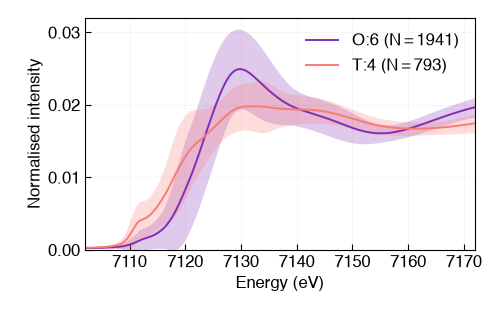

In [3]:
energies = prepare()
mask_o6 = processor.y == "O:6"
mask_t4 = processor.y == "T:4"

fig, ax = plt.subplots(figsize=FIGSIZE)
for class_mask, color, label in [
    (mask_o6, OH_COLOR, rf"O:6 ($N={mask_o6.sum()}$)"),
    (mask_t4, TD_COLOR, rf"T:4 ($N={mask_t4.sum()}$)"),
]:
    spectra = processor.X[class_mask, :]
    mean, std = spectra.mean(axis=0), spectra.std(axis=0)
    ax.plot(energies, mean, lw=1.4, color=color, label=label)
    ax.fill_between(energies, mean - std, mean + std, color=color, alpha=0.25, lw=0)

ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(bottom=0)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalised intensity")
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "dataset_spectra.pdf"), dpi=DPI)
print("Saved dataset_spectra.pdf")

## Outlier screening

Saved outlier_screening.pdf (129 of 2863 removed)


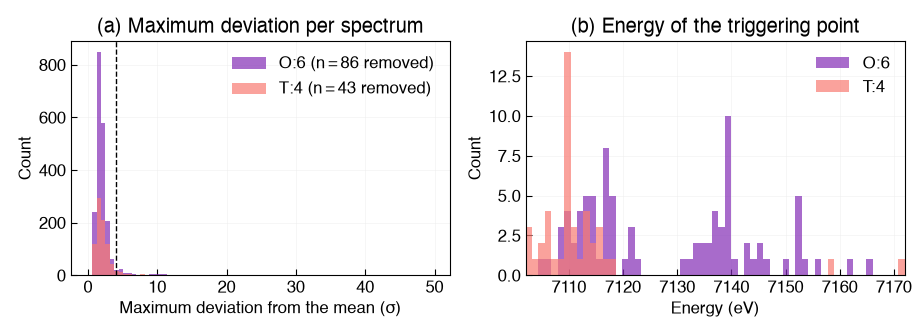

In [4]:
# Outlier screening diagnostics, computed on the trimmed, un-normalised spectra,
# i.e. the state in which Processor.remove_outliers sees them in the pipeline.
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)
energies = processor.metas[0]["energies"] + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]

# Replicate the per-point statistics used internally by Processor.remove_outliers.
MIN_STD = 0.01  # The remove_outliers default standard-deviation floor.
X_all, y_all = processor.X, processor.y
mean = X_all.mean(axis=0)
std = X_all.std(axis=0, ddof=0)
effective_std = np.maximum(std, MIN_STD * np.max(np.abs(mean)))
n_std = np.abs(X_all - mean) / effective_std
max_n_std = n_std.max(axis=1)
worst_energy = energies[n_std.argmax(axis=1)]
removed = max_n_std > OUTLIER_THRESHOLD

fig, (ax_a, ax_b) = plt.subplots(
    1, 2, figsize=(9.227, 3.364)
)  # Each panel matches the data area of the main-text Figure 1.

bins_a = np.linspace(0, max_n_std.max(), 80)
for color, label, tex in [(OH_COLOR, "O:6", "O:6"), (TD_COLOR, "T:4", "T:4")]:
    cls = y_all == label
    ax_a.hist(
        max_n_std[cls],
        bins=bins_a,
        color=color,
        alpha=0.7,
        lw=0,
        label=rf"{tex} ($n={int((cls & removed).sum())}$ removed)",
    )
ax_a.axvline(OUTLIER_THRESHOLD, color="k", ls="--", lw=1)
ax_a.set_title("(a) Maximum deviation per spectrum")
ax_a.set_xlabel(r"Maximum deviation from the mean ($\sigma$)")
ax_a.set_ylabel("Count")
ax_a.legend(loc="upper right", frameon=False)

bins_b = np.linspace(energies[0], energies[-1], 60)
for color, label, tex in [(OH_COLOR, "O:6", "O:6"), (TD_COLOR, "T:4", "T:4")]:
    cls = (y_all == label) & removed
    ax_b.hist(worst_energy[cls], bins=bins_b, color=color, alpha=0.7, lw=0, label=tex)
ax_b.set_title("(b) Energy of the triggering point")
ax_b.set_xlabel("Energy (eV)")
ax_b.set_ylabel("Count")
ax_b.set_xlim(energies[0], energies[-1])
ax_b.legend(loc="upper right", frameon=False)

for ax in (ax_a, ax_b):
    ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(direction="in", length=4, top=False, right=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "outlier_screening.pdf"), dpi=DPI)
print(f"Saved outlier_screening.pdf ({int(removed.sum())} of {len(removed)} removed)")

## Poisson-noise illustration

Saved noise_spectra.pdf


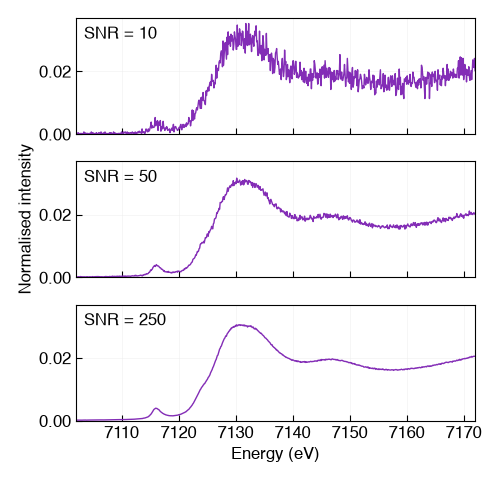

In [5]:
MATERIAL_TO_PLOT = "mp-19770"  # Hematite: one Fe site, octahedral.

# One panel per SNR. Overlaid traces hide everything but the noisiest one.
spectra = {}
for snr in SELECTED_SNRS:
    # Hematite is in the training set, so the noise goes on the whole dataset. The
    # spectra must stay un-normalised until the noise is added.
    energies = prepare(normalize=False)
    processor.add_poisson_noise(
        snr=snr,
        reference_intensity=FE_REFERENCE_MBARN,
        normalization=NORMALIZATION,
        reference=energies,
        random_seed=RANDOM_SEED,
    )
    idx = next(
        i
        for i, meta in enumerate(processor.metas)
        if meta["material_id"] == MATERIAL_TO_PLOT
    )
    spectra[snr] = processor.X[idx].copy()

fig, axes = plt.subplots(len(SELECTED_SNRS), 1, figsize=(5, 4.8), sharex=True)
# A shared vertical scale, so the per-point noise compares directly across panels.
ymax = 1.05 * max(spectrum.max() for spectrum in spectra.values())
for ax, snr in zip(axes, SELECTED_SNRS):
    ax.plot(energies, spectra[snr], lw=1, color=NOISE_COLOR)
    ax.text(0.02, 0.93, f"SNR = {snr}", transform=ax.transAxes, va="top", ha="left")
    ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(direction="in", length=4, top=False, right=False)
    ax.set_xlim(energies[0], energies[-1])
    ax.set_ylim(0, ymax)

axes[len(axes) // 2].set_ylabel("Normalised intensity")
axes[-1].set_xlabel("Energy (eV)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "noise_spectra.pdf"), dpi=DPI)
print("Saved noise_spectra.pdf")

## Augmentation, panel (a): random forest under Poisson noise

In [6]:
# Original RF.
prepare()
rf = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
rf.fit(processor.X_train, processor.y_train)

# Noise-augmented RF (two thirds of the training set, SNR 10-250).
energies = prepare(normalize=False)
processor.augment(
    energies=energies,
    fraction=2 / 3,
    snr_range=(10, 250),
    noise_reference_intensity=FE_REFERENCE_MBARN,
    shift_range=None,
    normalization=NORMALIZATION,
    random_seed=RANDOM_SEED,
)
rf_aug = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
rf_aug.fit(processor.X_train, processor.y_train)

rf_orig_noise, rf_aug_noise = [], []
for snr in SNRS:
    prepare(snr=snr)
    rf_orig_noise.append(
        calculate_accuracies(processor.y_test, rf.predict(processor.X_test))["balanced"]
    )
    rf_aug_noise.append(
        calculate_accuracies(processor.y_test, rf_aug.predict(processor.X_test))[
            "balanced"
        ]
    )

print("RF noise (orig):", [f"{v:.3f}" for v in rf_orig_noise])
print("RF noise (aug): ", [f"{v:.3f}" for v in rf_aug_noise])

RF noise (orig): ['0.582', '0.864', '0.910', '0.926', '0.926']
RF noise (aug):  ['0.601', '0.884', '0.924', '0.930', '0.933']


## Augmentation, panel (b): CNN under energy shifts

In [7]:
label_encoder = LabelEncoder()
cnn_orig = keras.models.load_model(
    os.path.join(MODELS_DIR, "cnn_classifier.keras"), compile=False
)
cnn_aug = keras.models.load_model(
    os.path.join(MODELS_DIR, "cnn_classifier_augmented.keras"), compile=False
)

cnn_orig_shift, cnn_aug_shift = [], []
for shift in SHIFTS:
    prepare(shift=shift, encode=True, cnn_split=True)
    y_test = label_encoder.inverse_transform(processor.y_test)
    p_orig = (
        cnn_orig.predict(processor.X_test, verbose=0).ravel() >= THRESHOLD
    ).astype(int)
    p_aug = (cnn_aug.predict(processor.X_test, verbose=0).ravel() >= THRESHOLD).astype(
        int
    )
    cnn_orig_shift.append(
        calculate_accuracies(y_test, label_encoder.inverse_transform(p_orig))[
            "balanced"
        ]
    )
    cnn_aug_shift.append(
        calculate_accuracies(y_test, label_encoder.inverse_transform(p_aug))["balanced"]
    )

print("CNN shift (orig):", [f"{v:.3f}" for v in cnn_orig_shift])
print("CNN shift (aug): ", [f"{v:.3f}" for v in cnn_aug_shift])

CNN shift (orig): ['0.915', '0.914', '0.923', '0.923', '0.901']
CNN shift (aug):  ['0.922', '0.924', '0.921', '0.919', '0.911']


## Augmentation figure (two equal panels)

Saved augmentation_comparison.pdf


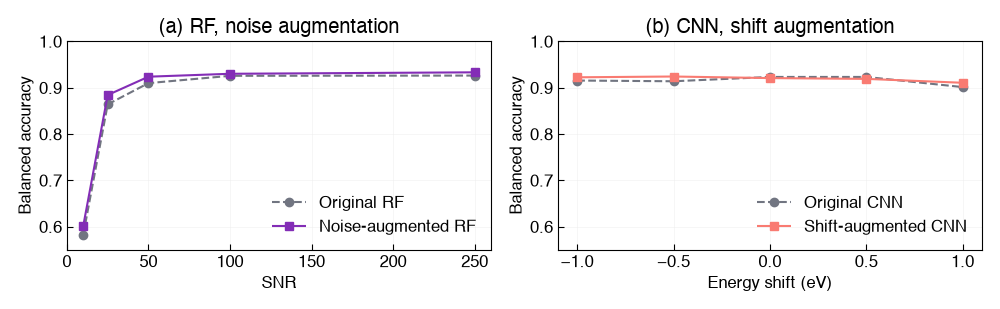

In [8]:
# Two equal panels, each the same size as the one-panel figures.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(2 * FIGSIZE[0], FIGSIZE[1]))

ax_a.plot(
    SNRS, rf_orig_noise, marker="o", ls="--", color=ORIGINAL_COLOR, label="Original RF"
)
ax_a.plot(
    SNRS, rf_aug_noise, marker="s", ls="-", color=OH_COLOR, label="Noise-augmented RF"
)
ax_a.set_title("(a) RF, noise augmentation")
ax_a.set_xlabel("SNR")
ax_a.set_xlim(0, 260)

ax_b.plot(
    SHIFTS,
    cnn_orig_shift,
    marker="o",
    ls="--",
    color=ORIGINAL_COLOR,
    label="Original CNN",
)
ax_b.plot(
    SHIFTS,
    cnn_aug_shift,
    marker="s",
    ls="-",
    color=TD_COLOR,
    label="Shift-augmented CNN",
)
ax_b.set_title("(b) CNN, shift augmentation")
ax_b.set_xlabel("Energy shift (eV)")

for ax in (ax_a, ax_b):
    ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(direction="in", length=4, top=False, right=False)
    ax.set_ylim(0.55, 1.0)
    ax.set_ylabel("Balanced accuracy")
    ax.legend(loc="lower right", frameon=False)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "augmentation_comparison.pdf"), dpi=DPI)
print("Saved augmentation_comparison.pdf")

## Baseline confusion matrices (RF and CNN on clean data)

Saved baseline_cm.pdf


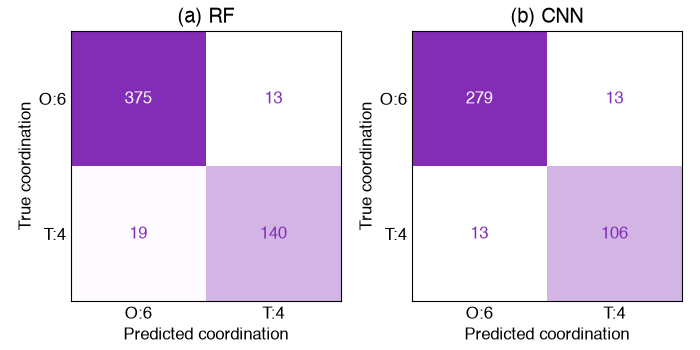

In [9]:
# Confusion matrices on the unperturbed test set, RF and CNN, as one composite figure.
fig, (ax_rf, ax_cnn) = plt.subplots(1, 2, figsize=(7, 3.5))

prepare()
cm_rf = confusion_matrix(processor.y_test, rf.predict(processor.X_test), labels=LABELS)
ConfusionMatrixDisplay(cm_rf, display_labels=LABELS).plot(
    ax=ax_rf, colorbar=False, values_format="d", cmap=DEFAULT_CM_CMAP
)
ax_rf.set_title("(a) RF")

prepare(encode=True, cnn_split=True)
y_test = label_encoder.inverse_transform(processor.y_test)
p_cnn = (cnn_orig.predict(processor.X_test, verbose=0).ravel() >= THRESHOLD).astype(int)
cm_cnn = confusion_matrix(y_test, label_encoder.inverse_transform(p_cnn), labels=LABELS)
ConfusionMatrixDisplay(cm_cnn, display_labels=LABELS).plot(
    ax=ax_cnn, colorbar=False, values_format="d", cmap=DEFAULT_CM_CMAP
)
ax_cnn.set_title("(b) CNN")

for ax in (ax_rf, ax_cnn):
    ax.set(xlabel="Predicted coordination", ylabel="True coordination")
    ax.tick_params(length=0)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "baseline_cm.pdf"), dpi=DPI)
print("Saved baseline_cm.pdf")

## Spectral ablation importance (RF and CNN)

Saved spectral_ablation.pdf


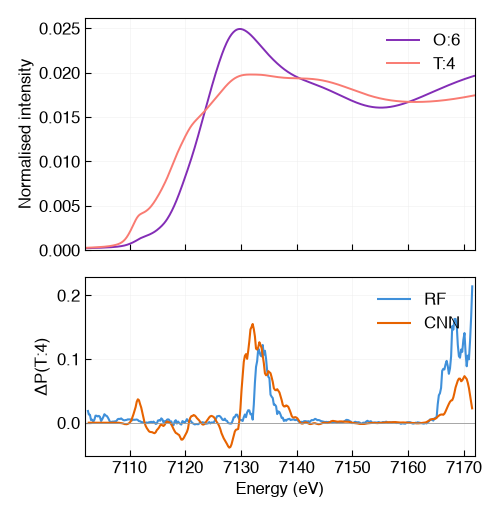

In [10]:
# Spectral ablation importance for the RF and CNN (Figure: spectral_ablation.pdf).
# A sliding window of the spectrum is replaced by the training-set mean and the
# drop in the predicted T:4 probability is recorded; this uses forward passes
# only, so the identical procedure applies to both models.
label_encoder = LabelEncoder()
WINDOW, STEP = 10, 2
RF_COLOR, CNN_COLOR = "#3f90da", "#e76300"


def ablation_curve(predict_t4, x_t4, baseline, n_points):
    base = predict_t4(x_t4)
    curve = np.full(n_points, np.nan)
    for c in range(0, n_points - WINDOW, STEP):
        ablated = x_t4.copy()
        ablated[:, c : c + WINDOW] = baseline[c : c + WINDOW]
        curve[c + WINDOW // 2] = np.mean(base - predict_t4(ablated))
    return curve


# Random forest on its 80/20 split.
energies = prepare()
rf = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED, class_weight="balanced"
)
rf.fit(processor.X_train, processor.y_train)
t4_col = list(rf.classes_).index("T:4")
rf_x_t4 = processor.X_test[processor.y_test == "T:4"].astype("float32")
rf_baseline = processor.X_train.mean(axis=0).astype("float32")
rf_ablation = ablation_curve(
    lambda a: rf.predict_proba(a)[:, t4_col], rf_x_t4, rf_baseline, len(energies)
)

# CNN on its 70/15/15 split; the sigmoid output is P(T:4).
energies = prepare(encode=True, cnn_split=True)
cnn = keras.models.load_model(os.path.join(MODELS_DIR, "cnn_classifier.keras"))
t4_int = label_encoder.transform(["T:4"])[0]
cnn_x_t4 = processor.X_test[processor.y_test == t4_int].astype("float32")
cnn_baseline = processor.X_train.mean(axis=0).astype("float32")
cnn_ablation = ablation_curve(
    lambda a: cnn.predict(a, verbose=0).reshape(-1),
    cnn_x_t4,
    cnn_baseline,
    len(energies),
)

# Reference class means.
energies = prepare()
mean_o6 = processor.X[processor.y == "O:6"].mean(axis=0)
mean_t4 = processor.X[processor.y == "T:4"].mean(axis=0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 5.15), height_ratios=[1.3, 1]
)
ax_top.plot(energies, mean_o6, color=OH_COLOR, lw=1.4, label="O:6")
ax_top.plot(energies, mean_t4, color=TD_COLOR, lw=1.4, label="T:4")
ax_top.set_ylabel("Normalised intensity")
ax_top.set_ylim(bottom=0)
ax_top.legend(loc="upper right", frameon=False)

valid = ~np.isnan(rf_ablation)
ax_bot.plot(energies[valid], rf_ablation[valid], color=RF_COLOR, lw=1.5, label="RF")
valid = ~np.isnan(cnn_ablation)
ax_bot.plot(energies[valid], cnn_ablation[valid], color=CNN_COLOR, lw=1.5, label="CNN")
ax_bot.axhline(0, color="0.6", lw=0.6)
ax_bot.set_ylabel(r"$\Delta P$(T:4)")
ax_bot.set_xlabel("Energy (eV)")
ax_bot.legend(loc="upper right", frameon=False)

for ax in (ax_top, ax_bot):
    ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(direction="in", length=4, top=False, right=False)
    ax.set_xlim(energies[0], energies[-1])
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "spectral_ablation.pdf"), dpi=DPI)
print("Saved spectral_ablation.pdf")

## Mechanism of the shift asymmetry

Per-class recall vs shift (for the SI table):
shift   [-1.0, -0.5, 0.0, 0.5, 1.0]
RF  O:6 [96.4, 97.2, 96.6, 96.4, 96.4]
RF  T:4 [83.6, 88.7, 88.1, 86.8, 82.4]
CNN O:6 [93.2, 94.5, 95.5, 95.5, 94.5]
CNN T:4 [89.9, 88.2, 89.1, 89.1, 85.7]
Saved shift_mechanism.pdf


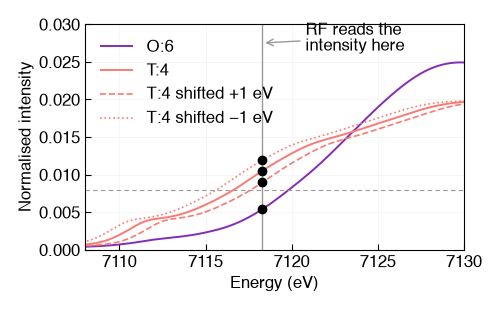

In [11]:
# Mechanism of the shift asymmetry (Figure: shift_mechanism.pdf).
# Reuses the random forest (rf) and CNN (cnn) trained in the cell above.
from xasml.models.data import shift_features

# Class means and the most-discriminating bin on the rising edge.
grid = prepare()
mean_o6 = processor.X[processor.y == "O:6"].mean(axis=0)
mean_t4 = processor.X[processor.y == "T:4"].mean(axis=0)
relative = grid - ENERGY_SHIFT
rising = (relative > 3) & (relative < 12)
e0 = np.where(rising)[0][np.argmax(mean_t4[rising] - mean_o6[rising])]
t4_up = shift_features(mean_t4.reshape(1, -1), +10).ravel()
t4_dn = shift_features(mean_t4.reshape(1, -1), -10).ravel()

# Per-class recall as a function of a rigid energy shift, for each model.
# These values are tabulated in the Supporting Information (Table S2); the T:4
# rows also appear in the manuscript shift discussion.
rf_o6, rf_t4, cnn_o6, cnn_t4 = [], [], [], []
t4_int = label_encoder.transform(["T:4"])[0]
o6_int = label_encoder.transform(["O:6"])[0]
for s in SHIFTS:
    prepare(shift=s)
    yp = rf.predict(processor.X_test)
    rf_o6.append(np.mean(yp[processor.y_test == "O:6"] == "O:6") * 100)
    rf_t4.append(np.mean(yp[processor.y_test == "T:4"] == "T:4") * 100)
    prepare(shift=s, encode=True, cnn_split=True)
    yp = (cnn.predict(processor.X_test, verbose=0).ravel() >= THRESHOLD).astype(int)
    cnn_o6.append(np.mean(yp[processor.y_test == o6_int] == o6_int) * 100)
    cnn_t4.append(np.mean(yp[processor.y_test == t4_int] == t4_int) * 100)
# Kept for the figure annotations and any downstream use.
rf_recall, cnn_recall = rf_t4, cnn_t4
print("Per-class recall vs shift (for the SI table):")
print("shift  ", SHIFTS)
print("RF  O:6", [round(float(v), 1) for v in rf_o6])
print("RF  T:4", [round(float(v), 1) for v in rf_t4])
print("CNN O:6", [round(float(v), 1) for v in cnn_o6])
print("CNN T:4", [round(float(v), 1) for v in cnn_t4])

# Figure: the RF thresholds the intensity at a fixed energy on the rising edge.
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(grid, mean_o6, color=OH_COLOR, lw=1.4, label="O:6")
ax.plot(grid, mean_t4, color=TD_COLOR, lw=1.4, label="T:4")
ax.plot(grid, t4_up, color=TD_COLOR, lw=1.2, ls="--", label="T:4 shifted $+1$ eV")
ax.plot(grid, t4_dn, color=TD_COLOR, lw=1.2, ls=":", label="T:4 shifted $-1$ eV")
ax.axvline(grid[e0], color="0.6", lw=1)
threshold = 0.5 * (mean_t4[e0] + mean_o6[e0])
ax.axhline(threshold, color="0.6", lw=0.8, ls=(0, (4, 3)))
for value in (mean_o6[e0], mean_t4[e0], t4_up[e0], t4_dn[e0]):
    ax.plot(grid[e0], value, "o", ms=6, color="k", zorder=5)
ax.annotate(
    "RF reads the\nintensity here",
    (grid[e0], 0.0275),
    (grid[e0] + 2.5, 0.0265),
    arrowprops=dict(arrowstyle="->", color="0.6"),
)
ax.set_xlim(7108, 7130)
ax.set_ylim(0, 0.03)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Normalised intensity")
ax.legend(loc="upper left", frameon=False)
ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "shift_mechanism.pdf"), dpi=DPI)
print("Saved shift_mechanism.pdf")

## FDMNES spectral broadening 

Saved fdmnes_broadening.pdf


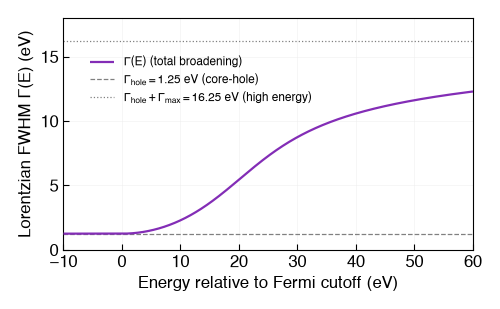

In [12]:
# Energy-dependent Lorentzian broadening profile (Figure: fdmnes_broadening.pdf).
e_rel = np.linspace(-10, 60, 701)
e_cut = 0.0
e_cent = 30.0
e_larg = 30.0
gamma_hole = 1.25
gamma_max = 15.0


def arctan_gammas(
    x, x_cut=0.0, x_cent=30.0, x_larg=30.0, gamma_hole=1.25, gamma_max=15.0
):
    f = np.maximum((x - x_cut) / x_cent, 1e-6)
    a = np.pi * gamma_max * (f - 1.0 / f**2) / (3.0 * x_larg)
    gammas = gamma_hole + gamma_max * (0.5 + (1.0 / np.pi) * np.arctan(a))
    gammas[x < x_cut] = gamma_hole
    return gammas


gammas = arctan_gammas(e_rel, e_cut, e_cent, e_larg, gamma_hole, gamma_max)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(
    e_rel,
    gammas,
    lw=1.6,
    color=OH_COLOR,
    label=r"$\Gamma(E)$ (total broadening)",
    zorder=3,
)
ax.axhline(
    gamma_hole,
    color="0.5",
    ls="--",
    lw=0.9,
    label=rf"$\Gamma_{{\mathrm{{hole}}}} = {gamma_hole}$ eV (core-hole)",
    zorder=2,
)
ax.axhline(
    gamma_hole + gamma_max,
    color="0.5",
    ls=":",
    lw=0.9,
    label=rf"$\Gamma_{{\mathrm{{hole}}}} + \Gamma_{{\mathrm{{max}}}} = {gamma_hole + gamma_max}$ eV (high energy)",
    zorder=2,
)

ax.set_xlabel("Energy relative to Fermi cutoff (eV)")
ax.set_ylabel(r"Lorentzian FWHM $\Gamma(E)$ (eV)")
ax.set_xlim(-10, 60)
ax.set_ylim(0, 18)
ax.grid(True, color="0.92", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(direction="in", length=4, top=False, right=False)
ax.legend(loc="center left", bbox_to_anchor=(0.04, 0.73), frameon=False, fontsize=8.5)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fdmnes_broadening.pdf"), dpi=DPI)
print("Saved fdmnes_broadening.pdf")
